# Calidad del vino 

integrantes:
Adrian Marcelo ballesteros Herrera 
Maria Fernanda Muñoz sevillla
Miguel Aaron Castillon Ochoa

---

## Objetivos: 

### generales: 
* El proposito es poder predecir la calidad del vino con diferentes variables cuantitativas como la acidez del vino, los sulfatos, el PH,etc... 

### especificos:

1. Analizar y limpiar nuestro dataset a traves de una EDA
2. Evaluar los modelos base (un arbol de decision solo o una regresion lineal) para tener un modelo referencia o un benchmark a superar
3. Implementar modelos mas avanzados como boosting o random forest, optimizando sus hiperparametros con una optimizacion bayesiana para poder obtener el mejor modelo posible
4. Comparar las metricas como $R^2$ o MSE de cada modelo mediante Cross-Validation y determinar cual ofrece mejor prediccion al vino

---

## Marco Teorico

### regresion lineal

* La regresion lineal es un metodo estadistico que busca predecir las variables independientes (calidad del vino) con las variables dependientes (datos fisicoquimicos del vino). minimizando la diferencia cuadratica entre las prediciones y los valores reales

* Los 6 principales problemas que se pueden encontrar en una regresion lineal son los siguientes:
1. No linealidad de los datos: La relación real puede no ser una línea recta.

2. Correlación de los términos de error: Los errores deben ser independientes; si siguen un patrón, el modelo falla.

3. Varianza no constante de los errores (Heterocedasticidad): El error no debe aumentar a medida que aumenta el valor predicho.

4. Valores atípicos (Outliers): Puntos inusuales en la variable "Y" que distorsionan el modelo.

5. untos de alto apalancamiento (High Leverage): Puntos inusuales en las variables "X" que "jalan" la línea de regresión hacia ellos.

6. Colinealidad: Cuando dos variables predictoras están muy correlacionadas entre sí, dificultando saber el efecto individual de cada una.

### Arbol para regresion

* Los arboles de decision es un diagrama en el que se representan las deicisones que se pueden tomar, los diferenes escenarios que pueden pasar.

* la meta de los arboles para regresion es minimizar la funcion de costo que es basicamente la suma de la diferencia cuadratica entre nuestra prediccion y el valor real, esto se hace con la division de las variables predictorias que den menos varianza en el resultado ejemplo se mide que variable es la que mas influye en el resultado y de ahi, se hace una division si X es mayor a 5(numero aleatorio para el ejemplo, no esta relacionado con el proyecto) va a la derecha y si es menor va a la izquierda. 

### Arbol para clasificacion:

* En el arbol de clasificacion se hace de forma de distinta ya que no queremos predecir el valor exacto, si no clasificar de forma correcta si va en el grupo A o en el grupo B esto se mide de dos formas distintas el indice de gini o la entropia, la entropia nos dice que tan revuelto estan nuestros datos y el indice de gini nos dice cual es la probabilidad de que tan a menudo nos equivocariamos si etiquetaramos de forma aleatoria, por ejemplo imaginate tres carritos de frutas, en uno hay puras manzanas, en otro manzanas y bananas (50-50) y en otro la gran mayoria son manzanas pero hay una que otra banana, en la entropia el primero nos saldria 0 pero en el segundo nos daria un 100% por que el desorden es total en este carrito, pero en el gini nos daria 0 en el primer caso por que no hay forma de etiquetarlos mal, son puras manzanas y en el segundo al ser un 50-50, es el peor caso posible. si tuvieramos la informacion como que tipo de uva es, se podria hacer una regresion clasificatoria que aporte a nuestro analisis pero por confidencialidad del viñedo, esto se nego.

formula de entropia:
$$D = - \sum_{k=1}^{K} \hat{p}_{mk} \log(\hat{p}_{mk})$$

fromula del indice de gini:

$$G = \sum_{k=1}^{K} \hat{p}_{mk} (1 - \hat{p}_{mk})$$



### Bootstrap

El método *bootstrap* es una técnica de remuestreo introducida por Bradley Efron en 1979 que permite estimar la variabilidad de un estadístico o modelo utilizando únicamente los datos disponibles. Su idea central consiste en generar nuevas muestras a partir del conjunto original mediante selección **con reemplazo**, lo que significa que una observación puede aparecer varias veces dentro de la misma muestra o no aparecer en absoluto.

Si el conjunto de datos original contiene $n$ observaciones, cada muestra bootstrap $D_k$ también tiene tamaño $n$, pero se genera de la siguiente manera:

$$
D_k = \{ x_1, x_2, \dots, x_n \} \quad \text{seleccionados con reemplazo}
$$

Una vez generadas estas muestras, se calcula un estadístico o se entrena un modelo sobre cada una. Al observar la variabilidad entre los resultados, es posible estimar la incertidumbre del modelo sin asumir distribuciones teóricas.

El bootstrap permite:

- Estimar la variabilidad de un estimador.
- Construir intervalos de confianza.
- Medir la estabilidad de un modelo.
- Reducir el riesgo de sobreajuste cuando se utiliza como base de métodos de ensamble.

Además, es un componente fundamental de técnicas como **bagging** y **Random Forest**, donde se entrenan múltiples modelos independientes utilizando diferentes muestras bootstrap. La combinación de estos modelos reduce la varianza y mejora la estabilidad. En ensambles de regresión, la predicción final se obtiene promediando las predicciones individuales:

$$
\hat{y}_{ensemble} = \frac{1}{K} \sum_{k=1}^{K} \hat{y}_k
$$

En resumen, el bootstrap es una herramienta flexible y poderosa que permite evaluar la incertidumbre de modelos y estimadores mediante la simulación de múltiples versiones del conjunto de datos original.

### Ensambles de modelos

Los ensambles de modelos son técnicas de aprendizaje automático que combinan varios modelos individuales para obtener un modelo final más preciso, estable y robusto. La idea principal es que la combinación de múltiples modelos puede corregir los errores que cada modelo comete por separado. Este enfoque se basa en el principio de que un grupo de modelos débiles puede producir un modelo fuerte cuando se combinan adecuadamente.

En un ensamble, cada modelo produce una predicción. En tareas de regresión, las predicciones suelen combinarse mediante un promedio:

$$
\hat{y}_{ensemble} = \frac{1}{K} \sum_{k=1}^{K} \hat{y}_k
$$

Para clasificación, la predicción final suele obtenerse por votación mayoritaria:

$$
\hat{y}_{ensemble} = \text{mode}(\hat{y}_1, \hat{y}_2, \dots, \hat{y}_K)
$$

Los ensambles permiten reducir el error del modelo gracias a la disminución de la varianza y, en algunos casos, del sesgo. Esto los hace más resistentes al ruido y más capaces de generalizar a nuevos datos. Muchos de los algoritmos más exitosos en la práctica, como Random Forest, XGBoost y Gradient Boosting, se basan en técnicas de ensamble.

En resumen, los ensambles de modelos aprovechan la fuerza colectiva de varios modelos para mejorar el rendimiento predictivo y ofrecer resultados más confiables que un modelo individual.


### **Bagging**

El *Bagging* (Bootstrap Aggregating), propuesto por Leo Breiman en 1996, es una técnica de ensamble que utiliza el método de bootstrap para entrenar múltiples modelos independientes y luego combinar sus predicciones. Su propósito principal es reducir la **varianza** del modelo, haciéndolo más estable y menos sensible al ruido de los datos.

El proceso de bagging consiste en:

1. Generar varias muestras bootstrap del conjunto de datos original.  
2. Entrenar un modelo independiente sobre cada una de esas muestras.  
3. Combinar las predicciones de todos los modelos.

En regresión, la combinación de predicciones se realiza mediante un promedio:

$$
\hat{y}_{bagging} = \frac{1}{K} \sum_{k=1}^{K} \hat{y}_k
$$

En clasificación, se utiliza votación mayoritaria:

$$
\hat{y}_{bagging} = \text{mode}(\hat{y}_1, \hat{y}_2, \dots, \hat{y}_K)
$$

Bagging funciona especialmente bien con modelos inestables, como los árboles de decisión, que pueden cambiar mucho si se modifica ligeramente el conjunto de entrenamiento. Al entrenar múltiples árboles en diferentes muestras y promediar sus predicciones, se obtiene un modelo final más robusto.

Un ejemplo ampliamente conocido de bagging es **Random Forest**, el cual añade un paso adicional de aleatoriedad al seleccionar subconjuntos de características en cada división del árbol.

En resumen, bagging reduce la varianza del modelo y mejora su capacidad de generalización mediante el uso de múltiples modelos entrenados en diferentes versiones del mismo dataset.


### **Boosting**

El *Boosting* es una técnica de ensamble que combina múltiples modelos débiles para formar un modelo fuerte. A diferencia del bagging, donde los modelos se entrenan de manera independiente, en boosting los modelos se entrenan **de forma secuencial**, y cada nuevo modelo intenta corregir los errores cometidos por los modelos anteriores.

La idea principal es que, si cada modelo individual es solo un poco mejor que el azar, al combinar muchos de ellos se puede obtener un modelo altamente preciso. Boosting se centra principalmente en **reducir el sesgo**, mejorando progresivamente la calidad del modelo.

En boosting, la predicción final se obtiene como una suma ponderada de los modelos individuales:

$$
\hat{y}(x) = \sum_{m=1}^{M} \alpha_m \, h_m(x)
$$

donde:

- $ h_m(x) $ es el modelo débil número $m$,
- $\alpha_m$ es el peso asignado a ese modelo según su desempeño.

En algoritmos como Gradient Boosting, cada modelo aprende a aproximar los **residuos** o errores del modelo anterior:

$$
r_i^{(m)} = y_i - \hat{y}^{(m-1)}(x_i)
$$

Esto permite que el modelo se ajuste iterativamente a los patrones difíciles del conjunto de datos.

Boosting ha dado lugar a métodos muy exitosos y utilizados, como **AdaBoost**, **Gradient Boosting**, **XGBoost**, **LightGBM**, y **CatBoost**. Estos algoritmos son capaces de lograr un alto rendimiento en tareas de regresión y clasificación, aunque pueden ser más propensos al sobreajuste si no se ajustan correctamente.

En resumen, boosting mejora el rendimiento del modelo al construir una secuencia de modelos que corrigen los errores del anterior, logrando una predicción final más precisa y con menor sesgo.


---

## Analisis del dataset:
   

* el dataset sacado de kaggle esta relacionado al viñedo portugues "Vinho Verde" que produce vine blanco y tinto. Por privacidad y 
problemas de logistica, solo variables fisicoquimicas y sensoriales, quitando cosas como el precio, el tipo de uva, la marca, etc
    

* Aun con la informacion restringida se intenta sacar la mayor informacion posible de las muestras por que queremos ser capaces de analizar cual es la calidad del vino. 




## Cargar el dataframe, limpieza y organizacion de este

In [1]:
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import statsmodels.api as sm
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from skopt import BayesSearchCV
from skopt.space import Real
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv("C:/Users/munoz/Downloads/lab_apre_est/winequality-red.csv")

df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.998,3.51,0.56,9.4,5.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.997,3.20,0.68,9.8,5.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0.65,9.8,5.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.998,3.16,0.58,9.8,6.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.998,3.51,0.56,9.4,5.0


In [5]:
# Información general del dataset
print("Dimensiones del dataset:", df.shape)
print("\nInformación de columnas:")
print(df.info())

print("\nEstadísticos descriptivos:")
df.describe()


Dimensiones del dataset: (1599, 12)

Información de columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   float64
dtypes: float64(12)
memory usage: 150.0 KB
None

Estadísticos descriptivos:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996752,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001891,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990000,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.996000,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.997000,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.998000,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.004000,4.010000,2.000000,14.900000,8.000000


In [7]:
# ¿Hay valores nulos?
df.isna().sum()


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [9]:
# Búsqueda de filas duplicadas
duplicados = df.duplicated().sum()
print("Filas duplicadas:", duplicados)

Filas duplicadas: 240


In [11]:
# Eliminación de duplicados 
if duplicados > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Nuevo tamaño del dataset:", df.shape)

Nuevo tamaño del dataset: (1359, 12)


In [13]:
# Asegurarnos de que 'quality' es numérica entera
df["quality"] = df["quality"].astype(int)
df["quality"].value_counts().sort_index()

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

## Modelo 1: Random forest

In [16]:
# Definimos X e y 
X = df.drop(columns=["quality"])
y = df["quality"]

In [18]:
kfold = KFold(
    n_splits=5,        
    shuffle=True,      
    random_state=42    
)

In [20]:
rf_base = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [22]:
rmse_scores_base = cross_val_score(
    rf_base,
    X,
    y,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rmse_scores_base = -rmse_scores_base  

print("Random Forest BASE - RMSE por fold:", rmse_scores_base)
print("Random Forest BASE - RMSE media:", rmse_scores_base.mean())
print("Random Forest BASE - RMSE std:", rmse_scores_base.std())

Random Forest BASE - RMSE por fold: [0.62248228 0.64667561 0.64986169 0.65166642 0.66216156]
Random Forest BASE - RMSE media: 0.6465695115632574
Random Forest BASE - RMSE std: 0.013115904929882325


In [23]:
r2_scores_base = cross_val_score(
    rf_base,
    X,
    y,
    cv=kfold,
    scoring="r2",
    n_jobs=-1
)

print("Random Forest BASE - R2 por fold:", r2_scores_base)
print("Random Forest BASE - R2 media:", r2_scores_base.mean())
print("Random Forest BASE - R2 std:", r2_scores_base.std())


Random Forest BASE - R2 por fold: [0.45298089 0.35065545 0.38974728 0.36960835 0.34020185]
Random Forest BASE - R2 media: 0.38063876224776955
Random Forest BASE - R2 std: 0.03993034531193283


In [26]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,                            
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

search.fit(X, y)

print("Mejores hiperparámetros:")
print(search.best_params_)
print("\nMejor score:", search.best_score_)

Mejores hiperparámetros:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20}

Mejor score: -0.6388046244058128


In [28]:
best_rf = search.best_estimator_
best_rf


RandomForestRegressor(max_depth=20, max_features='log2', min_samples_leaf=4,
                      n_estimators=300, n_jobs=-1, random_state=42)

In [30]:
rmse_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rmse_scores = -rmse_scores

print("Random Forest OPTIMIZADO - RMSE por fold:", rmse_scores)
print("Random Forest OPTIMIZADO - RMSE media:", rmse_scores.mean())
print("Random Forest OPTIMIZADO - RMSE std:", rmse_scores.std())

Random Forest OPTIMIZADO - RMSE por fold: [0.61507488 0.63346967 0.64065024 0.65367242 0.65115591]
Random Forest OPTIMIZADO - RMSE media: 0.6388046244058128
Random Forest OPTIMIZADO - RMSE std: 0.013918147388306065


In [32]:
r2_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=kfold,
    scoring="r2",
    n_jobs=-1
)

print("Random Forest OPTIMIZADO - R2 por fold:", r2_scores)
print("Random Forest OPTIMIZADO - R2 media:", r2_scores.mean())
print("Random Forest OPTIMIZADO - R2 std:", r2_scores.std())


Random Forest OPTIMIZADO - R2 por fold: [0.46592224 0.37690553 0.4069247  0.36572134 0.36195233]
Random Forest OPTIMIZADO - R2 media: 0.3954852268232666
Random Forest OPTIMIZADO - R2 std: 0.03859477629554996


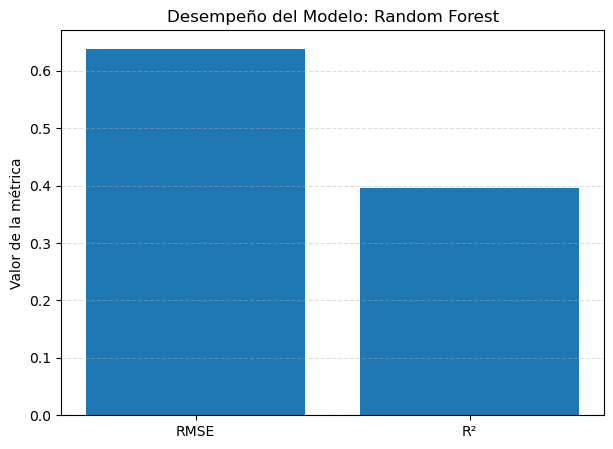

In [34]:
plt.figure(figsize=(7,5))
plt.bar(['RMSE', 'R²'], 
        [rmse_scores.mean(), r2_scores.mean()], 
        capsize=8)

plt.title("Desempeño del Modelo: Random Forest")
plt.ylabel("Valor de la métrica")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

| Modelo                  | Métrica | Media     | Desviación estándar |
|-------------------------|---------|-----------|----------------------|
| RF base (5-fold CV)     | RMSE    | 0.6466    | 0.0131               |
| RF base (5-fold CV)     | R²      | 0.3806    | 0.0399               |
| RF optimizado (5-fold)  | RMSE    | 0.6388    | 0.0139               |
| RF optimizado (5-fold)  | R²      | 0.3955    | 0.0386               |


In [36]:
importances = best_rf.feature_importances_
feature_names = X.columns

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance


,feature,importance
10,alcohol,0.241919
9,sulphates,0.158609
1,volatile acidity,0.140990
6,total sulfur dioxide,0.081101
2,citric acid,0.071322
4,chlorides,0.063009
0,fixed acidity,0.054966
8,pH,0.051428
7,density,0.049617
3,residual sugar,0.044831


<Figure size 800x500 with 0 Axes>

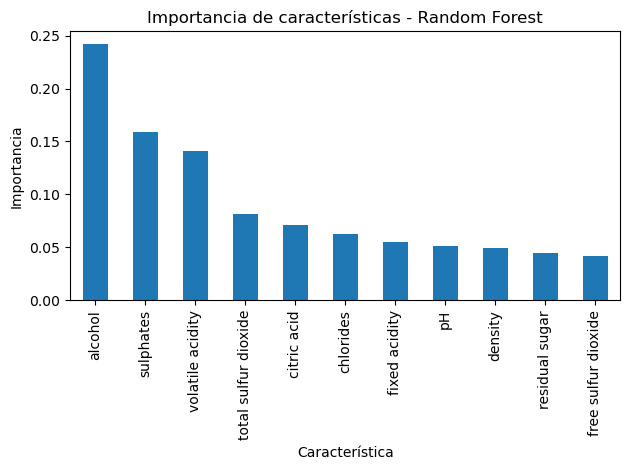

In [38]:

plt.figure(figsize=(8, 5))
feature_importance.plot(
    x="feature",
    y="importance",
    kind="bar",
    legend=False
)
plt.title("Importancia de características - Random Forest")
plt.ylabel("Importancia")
plt.xlabel("Característica")
plt.tight_layout()
plt.show()


## Modelo 2: Xgboost

In [43]:
lr= LinearRegression()
lin_reg = LinearRegression()
kf= KFold(
    n_splits=5,        
    shuffle=True,      
    random_state=42    
)
# Cross validation (RMSE)
rmse_scores_lin = np.sqrt(-cross_val_score(
    lin_reg, X, y,
    cv=kf,
    scoring="neg_mean_squared_error"
))

r2_scores_lin = cross_val_score(
    lin_reg, X, y,
    cv=kf,
    scoring="r2"
)


print("RMSE promedio:", rmse_scores_lin.mean())
print("RMSE desviación:", rmse_scores_lin.std())
print("R² promedio:", r2_scores_lin.mean())
print("R² desviación:", r2_scores_lin.std())

RMSE promedio: 0.6646857657824646
RMSE desviación: 0.009973289580986254
R² promedio: 0.3462280736059967
R² desviación: 0.025596967134611275


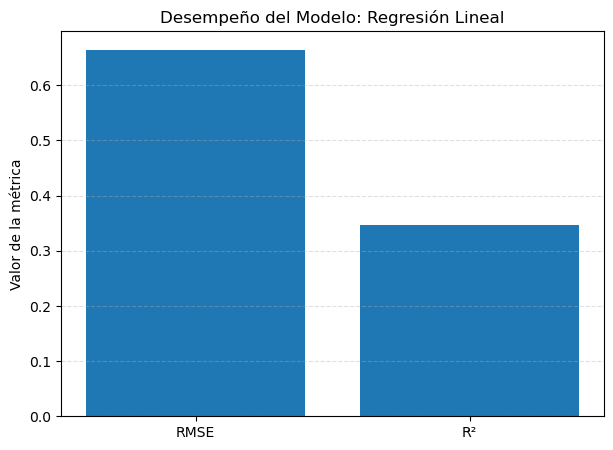

In [45]:
plt.figure(figsize=(7,5))
plt.bar(['RMSE', 'R²'], 
        [rmse_scores_lin.mean(), r2_scores_lin.mean()], 
        capsize=8)

plt.title("Desempeño del Modelo: Regresión Lineal")
plt.ylabel("Valor de la métrica")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

In [47]:
xgb_reg = XGBRegressor(random_state=42, n_estimators=200, learning_rate=0.1)
mse_scores_reg = []
r2_scores_reg = []

# ESPACIO DE BÚSQUEDA OPTIMIZADO
search_spaces= {
    "n_estimators": (100, 500),
    "max_depth": (3, 10),
    "learning_rate": (0.01, 0.3, "log-uniform"),
    "subsample": (0.5, 1.0, "uniform"),
    "colsample_bytree": (0.5, 1.0, "uniform"),
    "gamma": (0, 5),
    "reg_alpha": (0.0, 1.0, "uniform"),
    "reg_lambda": (0.0, 1.0, "uniform"),
}

opt_xgb = BayesSearchCV(
    estimator=xgb_reg,
    search_spaces=search_spaces,
    n_iter=30,
    cv=kfold,
    scoring="neg_mean_squared_error",   
    random_state=42,
    n_jobs=-1
)
opt_xgb.fit(X, y)

print("Mejores parámetros encontrados:")
print(opt_xgb.best_params_)




Mejores parámetros encontrados:
OrderedDict({'colsample_bytree': 1.0, 'gamma': 3, 'learning_rate': 0.03395138530749337, 'max_depth': 4, 'n_estimators': 454, 'reg_alpha': 0.0, 'reg_lambda': 0.6776454657961859, 'subsample': 0.5})


In [49]:
best_xgb = opt_xgb.best_estimator_

rmse_scores_xgb = np.sqrt(-cross_val_score(
    best_xgb, X, y, cv=kfold, scoring="neg_mean_squared_error"
))

r2_scores_xgb = cross_val_score(
    best_xgb, X, y, cv=kfold, scoring="r2"
)


print("RMSE promedio:", rmse_scores_xgb.mean())
print("RMSE desviación:", rmse_scores_xgb.std())
print("R² promedio:", r2_scores_xgb.mean())
print("R² desviación:", r2_scores_xgb.std())


RMSE promedio: 0.6396577747371742
RMSE desviación: 0.014912568194133969
R² promedio: 0.3936537027359009
R² desviación: 0.042192402199467814


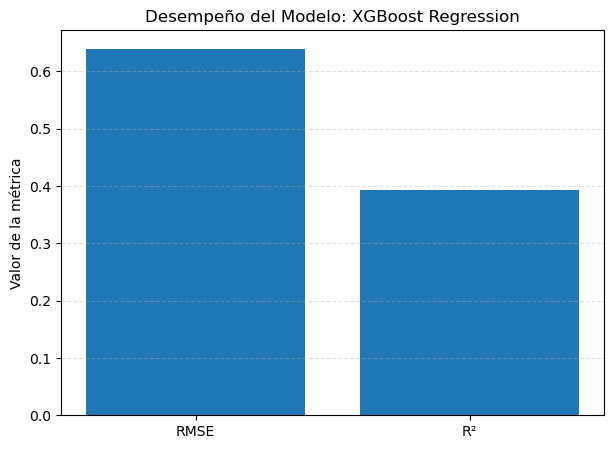

In [51]:
plt.figure(figsize=(7,5))
plt.bar(['RMSE', 'R²'], 
        [rmse_scores_xgb.mean(), r2_scores_xgb.mean()], 
        capsize=8)

plt.title("Desempeño del Modelo: XGBoost Regression")
plt.ylabel("Valor de la métrica")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

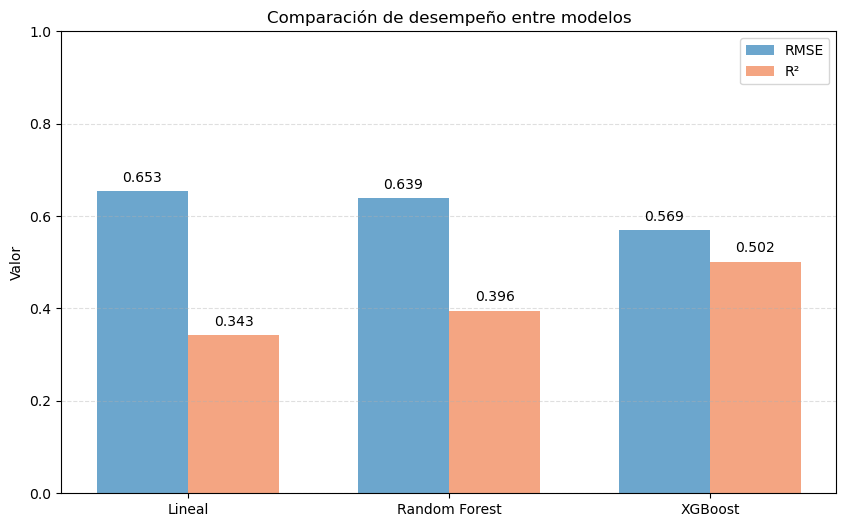

In [57]:
modelos = ["Lineal", "Random Forest", "XGBoost"]

# RMSE promedio
rmse_means = [0.6534, 0.6388, 0.5691]

# RMSE desviación estándar
rmse_stds = [0.0399, 0.0139, 0.0232]

# R² promedio
r2_means = [0.3427, 0.3955, 0.5016]

# R² desviación estándar
r2_stds = [0.0637, 0.0386, 0.0327]


x = np.arange(len(modelos))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, rmse_means, width, capsize=8, label="RMSE", color="#6CA6CD")
plt.bar(x + width/2, r2_means, width, capsize=8, label="R²", color="#F4A582")

plt.xticks(x, modelos)
plt.ylabel("Valor")
plt.title("Comparación de desempeño entre modelos")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)


for i in range(len(modelos)):
    plt.text(i - width/2, rmse_means[i] + 0.02, f"{rmse_means[i]:.3f}", ha='center', fontsize=10)
    plt.text(i + width/2, r2_means[i] + 0.02, f"{r2_means[i]:.3f}", ha='center', fontsize=10)

plt.show()

---
## Conclusiones 

Los resultados muestran que XGBoost es el mejor modelo para predecir la calidad del vino en comparación con Random Forest. Ya que XGBoost obtuvo un RMSE promedio menor y un R² promedio mayor, esto  indica que realiza predicciones más precisas y explica mejor la variabilidad de la variable objetivo. Además, presentó menor variabilidad entre folds, lo que demuestra que es un modelo más estable y consistente. En conjunto, estos resultados muestran que XGBoost captura de forma más efectiva las relaciones entre las características del vino y su calidad, superando al Random Forest tanto en precisión como en desempeño general.

### referencias
Berlanga, V., José, R. H. M., & Ruth, V. B. (2013, January 1). Cómo aplicar árboles de decisión en SPSS. https://diposit.ub.edu/items/e1f935b2-ee8c-42e0-ba8a-31f1e20e33ab

Díaz-Martínez, M. A., De Los Ángeles Ahumada-Cervantes, M., & Melo-Morín, J. P. (2021). Árboles de Decisión como Metodología para Determinar el Rendimiento Académico en Educación Superior. Revista Lasallista De Investigación, 18(2), 94–104. https://doi.org/10.22507/rli.v18n2a8
